In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from countcv.core.data import CountingDataset
from countcv.core.experiment_utils import load_mlflow_model
from countcv.focidet.train_linear_model import LinearDataset, gather_images


/home/raphael/01_projects/forschungsinteressen/rotationally-invariant-cnns/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/raphael/01_projects/forschungsinteressen/rotationally-invariant-cnns/.venv/lib/python3.12/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


# Constant model

In [2]:
data_dir = Path("../data/uc_cells")
tracking_uri = "../mlruns"
run_id = "2370bcf861794aac8f3b3266824305d1"
model = load_mlflow_model(tracking_uri, run_id).get_raw_model()
dataset_dmaps = LinearDataset(data_dir, set_type="val")
val_loader = DataLoader(dataset_dmaps, batch_size=4)
X_val, y_val = gather_images(val_loader, standardize=False, only_red_channel=True)
y_pred = model.predict(X_val)

MAE: 2.3932 | Mean value: 3.82


Text(0, 0.5, 'Count')

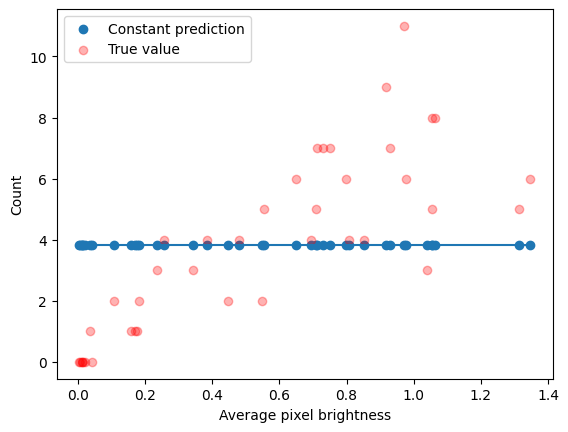

In [3]:
print(f"MAE: {abs(y_pred - y_val).mean():.4f} | Mean value: {model.constant_[0][0]:.2f}")
plt.scatter(X_val, y_pred, label="Constant prediction")
plt.scatter(X_val, y_val, color="red", alpha=0.3, label="True value")
plt.hlines([y_pred[0]], xmin=X_val.min(), xmax=X_val.max())
plt.legend()
plt.xlabel("Average pixel brightness")
plt.ylabel("Count")

# Linear model 

Fit a linear model in the average pixel brightness of the red channel

In [4]:
data_dir = Path("../data/uc_cells")
tracking_uri = "../mlruns"
run_id = "6170be9c242b48ce90ab0a87bd26067b"
model = load_mlflow_model(tracking_uri, run_id).get_raw_model()
dataset_dmaps = LinearDataset(data_dir, set_type="val")
val_loader = DataLoader(dataset_dmaps, batch_size=4)
X_val, y_val = gather_images(val_loader, standardize=False, only_red_channel=True)
y_pred = model.predict(X_val)

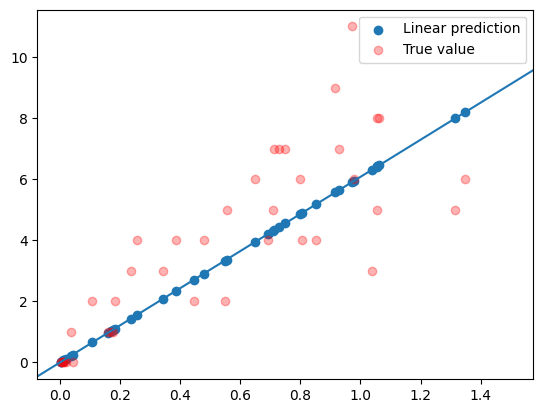

In [5]:
plt.scatter(X_val, y_pred, label="Linear prediction")
plt.scatter(X_val, y_val, color="red", alpha=0.3, label="True value")

x1, x2 = 0, 1.5
y1 = model.intercept_ + model.coef_ * x1
y2 = model.intercept_ + model.coef_ * x2
plt.axline((x1, y1[0]), (x2, y2[0]))
plt.legend()

MAE: 1.3005825281143188


Text(0, 0.5, 'Prediction')

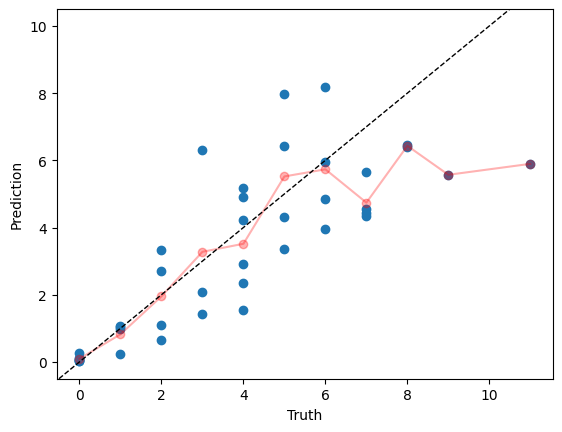

In [6]:
abs_error = abs(y_val - y_pred)

# Create a dataframe with ground truth and predictions
df = pd.DataFrame({"gt": y_val, "pred": y_pred})

# Group by ground truth and calculate mean predictions
grouped_means = df.groupby("gt")["pred"].mean()

print(f"MAE: {abs_error.mean()}")
plt.scatter(y_val, y_pred)
plt.plot(grouped_means.index, grouped_means.values, marker="o", color="red", alpha=0.3)
plt.axline((0, 0), (10, 10), color="black", linestyle="--", linewidth="1")
plt.xlabel("Truth")
plt.ylabel("Prediction")

# Densitymap model

In [7]:
model, transform = load_mlflow_model(tracking_uri, run_id="46be9633509b42b1937ad5fc10a0a85c")
model = model.get_raw_model()
dataset_dmaps = CountingDataset(
	data_dir,
	set_type="val",
	fetch_dot_labels=True,
	transform=transform,
)
val_loader = DataLoader(dataset_dmaps, batch_size=4)

In [8]:
device = "cuda"
alpha = 100

model.to(device)
model.eval()
y_val = torch.tensor([], dtype=torch.float, device=device)
y_pred = torch.tensor([], dtype=torch.float, device=device)

for img, label in val_loader:
	with torch.no_grad():
		img, label = img.to(device), label.to(device)
		outputs = model(img)
		y_val = torch.concat((y_val, label.sum(axis=(1, 2, 3)) / alpha))
		y_pred = torch.concat((y_pred, outputs.sum(axis=(1, 2, 3)) / alpha))

y_val = y_val.cpu().numpy()
y_pred = y_pred.cpu().numpy()

MAE: 0.6303409934043884


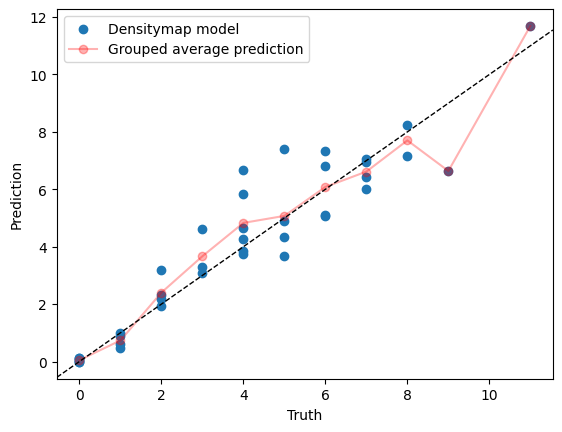

In [9]:
abs_error = abs(y_val - y_pred)

# Create a dataframe with ground truth and predictions
df = pd.DataFrame({"gt": y_val.astype(int), "pred": y_pred})

# Group by ground truth and calculate mean predictions
grouped_means = df.groupby("gt")["pred"].mean()


print(f"MAE: {abs_error.mean()}")
plt.scatter(y_val, y_pred, label="Densitymap model")
plt.plot(
	grouped_means.index, grouped_means.values, marker="o", color="red", alpha=0.3, label="Grouped average prediction"
)
plt.axline((0, 0), (10, 10), color="black", linestyle="--", linewidth="1")
plt.xlabel("Truth")
plt.ylabel("Prediction")
plt.legend()

# Ideen zu Unsicherheit

1. Mit Densitymaps an sich schwierig. Da gibt es keine spezifischen Optionen

2. Option A: Modellagnostische Methoden wie Conformal prediction (keine Ahnung wie gut das funktioniert und man verliert Trainingsdaten)

3. Option B: Brauchen wir das auf Bildebene? Eigentlich hätten wir doch gerne Unsicherheit auf Gallerieebene. Das kriegen wir mit der Poissonannahme direkt mit raus 

4. Option C: Frage: Tut es vielleicht auch ein Robustheitstest?  
	Da könnte man etwas mehr machen. z.B. ein wenig Rauschen einführen. Additiv oder multiplikativ / nur auf blauem Zellkern oder auf ganzem Bild / etc.  
Das habe ich mal ausprobiert

In [54]:
def add_small_noise(
	img_tensor: torch.Tensor, mean: float, intensity: float, additive: bool = True, masked: bool = True
):
	minval = img_tensor[:, 0, :, :].min()
	B, C, H, W = img_tensor.shape
	noise = intensity * torch.randn((B, H, W), device=img_tensor.device) + mean
	if masked:
		mask = img_tensor[:, 2, :, :] > (img_tensor[:, 2, :, :].min() + 0.01)
		noise = mask * noise
	if additive:
		img_tensor[:, 0, :, :] = (img_tensor[:, 0, :, :] + noise).clamp(min=minval)
	else:
		noise = noise + 1
		img_tensor[:, 0, :, :] = (img_tensor[:, 0, :, :] * noise).clamp(min=minval)
	return img_tensor, noise

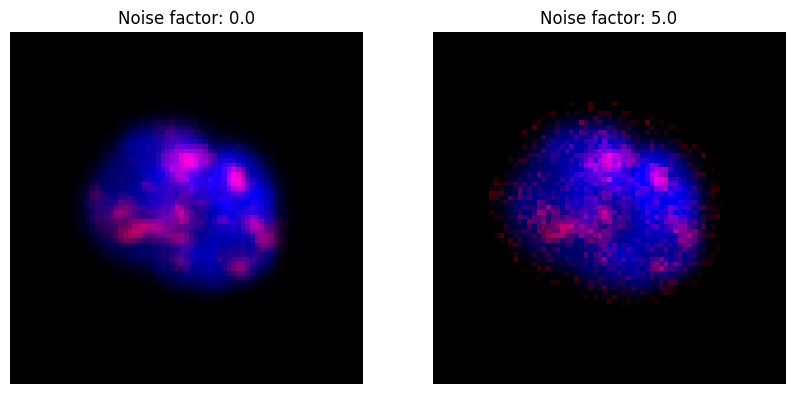

In [11]:
from copy import deepcopy

fig, axs = plt.subplots(ncols=2, figsize=(10, 6))
img, label = dataset_dmaps[0]
example_img = img.unsqueeze(0)

for intensity, ax in zip((0, 5), axs.flatten()):
	noised_img, noise = add_small_noise(deepcopy(example_img), mean=0, intensity=intensity, masked=True, additive=True)
	np_example_img = noised_img[0].permute(1, 2, 0).cpu().numpy()
	np_example_img = np_example_img[75:150, 75:150]
	for i in (0, 2):
		np_example_img[:, :, i] = (np_example_img[:, :, i] - np_example_img[:, :, i].min()) / (
			np_example_img[:, :, i].max()
		)
	ax.imshow(np_example_img)
	ax.set_title(f"Noise factor: {intensity:.1f}")
	ax.set_axis_off()

In [12]:
for intensity in np.arange(0, 6, 1):
	y_val = torch.tensor([], dtype=torch.float, device=device)
	y_pred = torch.tensor([], dtype=torch.float, device=device)
	for img, label in val_loader:
		with torch.no_grad():
			img, label = img.to(device), label.to(device)
			img, noise = add_small_noise(deepcopy(img), mean=0, intensity=intensity)
			outputs = model(img)
			y_val = torch.concat((y_val, label.sum(axis=(1, 2, 3)) / alpha))
			y_pred = torch.concat((y_pred, outputs.sum(axis=(1, 2, 3)) / alpha))

	y_val = y_val.cpu().numpy()
	y_pred = y_pred.cpu().numpy()
	mae = abs(y_val - y_pred).mean()
	print(f"Additive noise level: {intensity:.1f} | MAE: {mae}")

Additive noise level: 0.0 | MAE: 0.6303409934043884
Additive noise level: 1.0 | MAE: 0.641452431678772
Additive noise level: 2.0 | MAE: 0.7398505806922913
Additive noise level: 3.0 | MAE: 1.1810544729232788
Additive noise level: 4.0 | MAE: 2.1262104511260986
Additive noise level: 5.0 | MAE: 3.4688193798065186


In [ ]:
from tqdm import tqdm

list_maes = []
means = []
n = 30
intensities = np.arange(0, 6, 1)
for _ in tqdm(range(n)):
	mean = torch.randn(1).item()
	maes = []
	for intensity in intensities:
		y_val = torch.tensor([], dtype=torch.float, device=device)
		y_pred = torch.tensor([], dtype=torch.float, device=device)
		for img, label in val_loader:
			with torch.no_grad():
				img, label = img.to(device), label.to(device)
				img, noise = add_small_noise(img, mean=mean, intensity=intensity)
				outputs = model(img)
				y_val = torch.concat((y_val, label.sum(axis=(1, 2, 3)) / alpha))
				y_pred = torch.concat((y_pred, outputs.sum(axis=(1, 2, 3)) / alpha))

		y_val = y_val.cpu().numpy()
		y_pred = y_pred.cpu().numpy()
		mae = abs(y_val - y_pred).mean()
		maes.append(mae)
	list_maes.append(maes)
	means.append(mean)

100%|██████████| 30/30 [01:08<00:00,  2.28s/it]


<Axes: xlabel='intensities', ylabel='maes'>

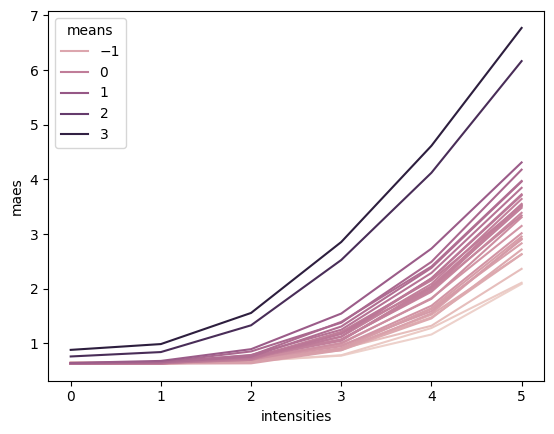

In [ ]:
import numpy as np
import seaborn as sns

maes = np.array(list_maes).flatten()
intensities_rep = np.repeat(intensities, n)
pd_means = np.array([[x] * 6 for x in means]).flatten()
df = pd.DataFrame({"intensities": intensities, "means": pd_means, "maes": maes})

sns.lineplot(df, x="intensities", y="maes", hue="means")

# Multiplicative noise

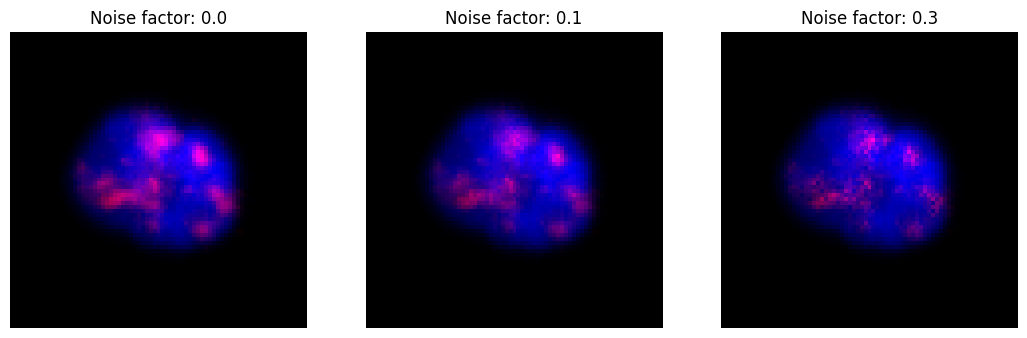

In [57]:
from copy import deepcopy

fig, axs = plt.subplots(ncols=3, figsize=(13, 6))
img, label = dataset_dmaps[0]
example_img = img.unsqueeze(0)

for intensity, ax in zip((0, 0.1, 0.3), axs.flatten()):
	noised_img, noise = add_small_noise(
		deepcopy(example_img), mean=0, intensity=intensity, masked=False, additive=False
	)
	np_example_img = noised_img[0].permute(1, 2, 0).cpu().numpy()
	np_example_img = np_example_img[75:150, 75:150]
	for i in (0, 2):
		np_example_img[:, :, i] = (np_example_img[:, :, i] - np_example_img[:, :, i].min()) / (
			np_example_img[:, :, i].max()
		)
	ax.imshow(np_example_img)
	ax.set_title(f"Noise factor: {intensity:.1f}")
	ax.set_axis_off()

In [ ]:
for intensity in np.arange(0, 0.6, 0.1):
	y_val = torch.tensor([], dtype=torch.float, device=device)
	y_pred = torch.tensor([], dtype=torch.float, device=device)
	for img, label in val_loader:
		with torch.no_grad():
			img, label = img.to(device), label.to(device)
			img, noise = add_small_noise(deepcopy(img), mean=0.2, intensity=intensity, additive=False)
			outputs = model(img)
			y_val = torch.concat((y_val, label.sum(axis=(1, 2, 3)) / alpha))
			y_pred = torch.concat((y_pred, outputs.sum(axis=(1, 2, 3)) / alpha))

	y_val = y_val.cpu().numpy()
	y_pred = y_pred.cpu().numpy()
	mae = abs(y_val - y_pred).mean()
	print(f"Multiplicative noise level: {intensity:.1f} | MAE: {mae}")

Multiplicative noise level: 0.0 | MAE: 1.1672769784927368
Multiplicative noise level: 0.1 | MAE: 1.2336078882217407
Multiplicative noise level: 0.2 | MAE: 1.5567092895507812
Multiplicative noise level: 0.3 | MAE: 1.9621238708496094
Multiplicative noise level: 0.4 | MAE: 2.4439873695373535
Multiplicative noise level: 0.5 | MAE: 3.2279574871063232


In [56]:
from tqdm import tqdm

list_maes = []
means = []
n = 30
intensities = np.arange(0, 0.6, 0.1)
for _ in tqdm(range(n)):
	mean = 0.2 * torch.randn(1).item()
	maes = []
	for intensity in intensities:
		y_val = torch.tensor([], dtype=torch.float, device=device)
		y_pred = torch.tensor([], dtype=torch.float, device=device)
		for img, label in val_loader:
			with torch.no_grad():
				img, label = img.to(device), label.to(device)
				img, noise = add_small_noise(img, mean=mean, intensity=intensity, masked=True, additive=False)
				outputs = model(img)
				y_val = torch.concat((y_val, label.sum(axis=(1, 2, 3)) / alpha))
				y_pred = torch.concat((y_pred, outputs.sum(axis=(1, 2, 3)) / alpha))

		y_val = y_val.cpu().numpy()
		y_pred = y_pred.cpu().numpy()
		mae = abs(y_val - y_pred).mean()
		maes.append(mae)
	list_maes.append(maes)
	means.append(mean)

100%|██████████| 30/30 [01:32<00:00,  3.08s/it]


<Axes: xlabel='intensities', ylabel='maes'>

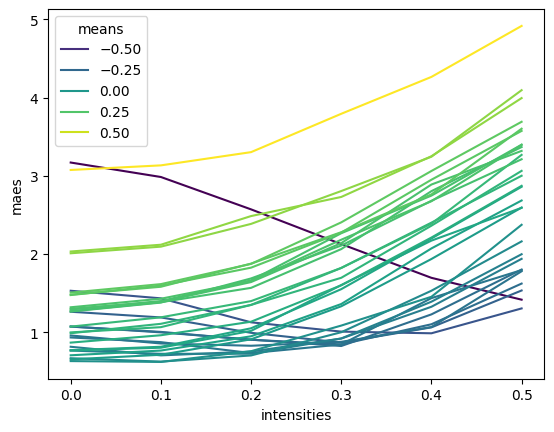

In [59]:
import numpy as np
import seaborn as sns

maes = np.array(list_maes).flatten()
intensities_rep = np.tile(intensities, n)
pd_means = np.array([[x] * 6 for x in means]).flatten()
df = pd.DataFrame({"intensities": intensities_rep, "means": pd_means, "maes": maes})

sns.lineplot(df, x="intensities", y="maes", hue="means", palette="viridis")